# 🏦 Guía de Estudio: Riesgo de Crédito con Machine Learning
 **Temas Cubiertos:** Fundamentos de Riesgo (PD, LGD, EL), Machine Learning para Crédito, Validación (Gini, KS) y Tratamiento de Desbalanceo.

Este notebook simula el ciclo de vida de un modelo de originación y su impacto en la rentabilidad del banco.

 ## 📚 Índice de Módulos

| # | Módulo | Concepto Clave |
|---|--------|----------------|
| 0 | Setup e Imports | Librerías y datos sintéticos con ruido |
| 1 | Datos Desbalanceados | Undersampling, Class Weight, XGBoost |
| 2 | Validación de Modelos | Gini, KS, ROC Curve |
| 3 | Impacto en Negocio | PD × LGD × EAD = EL |
| 4 | SQL para Riesgo | Cohortes, Window Functions |
| 5 | Backtesting y PSI | Estabilidad Out-of-Time |
| 6 | Scorecards | Calificación Paramétrica |
| 7 | XGBoost + Restricciones | Monotonicidad |
| 8 | Interpretabilidad | SHAP Values |

> **Tip de estudio:** Ejecuta cada celda en orden. El ruido en los datos (Módulo 0) simula la vida real: los modelos deben ser robustos a señales imperfectas.

---
## Módulo 0 — Setup: Instalación, Imports y Datos con Ruido

**Todos los imports están aquí.** Esto evita errores de "nombre no definido" en módulos posteriores.

### ¿Por qué añadir ruido al target?
En la vida real, el default no depende únicamente de variables financieras medibles. Factores no observables (enfermedad, divorcio, pérdida de empleo inesperada) generan **ruido irreducible**. Modelar esto hace que nuestras métricas sean más honestas y el modelo más robusto.

In [49]:
# ── Instalación (ejecutar solo si no tienes las librerías) ────────────────────
# !pip install xgboost shap

In [50]:
# ── Todos los imports en un solo lugar (buena práctica PEP-8) ─────────────────
import sqlite3
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

print('✅ Librerías cargadas')
print(f'   XGBoost : {xgb.__version__}')
print(f'   SHAP    : {shap.__version__}')

✅ Librerías cargadas
   XGBoost : 3.2.0
   SHAP    : 0.51.0


In [51]:
# ── Generación del Dataset Sintético con Ruido (15,000 solicitantes) ──────────
N = 15_000

data = {
    'ingreso_mensual':    np.random.normal(25_000, 8_000, N),
    'dti':                np.random.uniform(0.10, 0.70, N),
    'score_buro':         np.random.normal(650, 60, N),
    'antiguedad_laboral': np.random.uniform(0, 15, N),
    'monto_credito':      np.random.uniform(5_000, 120_000, N)
}
df = pd.DataFrame(data)

# ── Paso 1: Señal teórica (lógica financiera pura) ────────────────────────────
logit = (0.007 * (680 - df['score_buro'])
         + 3.5  * df['dti']
         - 0.0001 * df['ingreso_mensual'])
prob_default_teorica = 1 / (1 + np.exp(-logit))

# ── Paso 2: Ruido aleatorio (simula factores no observables en el mundo real) ─
#
# ⓘ Añadimos una perturbación Normal(0, 0.15) a la probabilidad teórica.
#    Esto simula que el default real tiene una componente irreducible que
#    ningún modelo puede capturar: enfermedades, divorcios, despidos repentinos.
#    Efecto esperado: el Gini bajará ~5-10 puntos respecto a un dataset limpio,
#    lo cual es más honesto y más parecido a producción real.
ruido           = np.random.normal(0, 0.15, N)
prob_default_real = np.clip(prob_default_teorica + ruido, 0, 1)

# ── Paso 3: Umbral sobre la probabilidad con ruido ────────────────────────────
df['default'] = (prob_default_real > 0.82).astype(int)

tasa = df['default'].mean() * 100
print(f'Registros        : {N:,}')
print(f'Tasa de Default  : {tasa:.2f}%  ← dataset desbalanceado')
print(f'Distribución     : {df["default"].value_counts().to_dict()}')

X = df.drop('default', axis=1)
y = df['default']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Registros        : 15,000
Tasa de Default  : 3.42%  ← dataset desbalanceado
Distribución     : {0: 14487, 1: 513}

Train: 10,500 | Test: 4,500


---
## Módulo 1 — Manejo de Datos Desbalanceados

Comparamos **seis modelos** agrupados en dos familias para ver qué estrategia de balanceo funciona mejor con datos ruidosos.

| Estrategia | Sklearn (RF/GBT) | XGBoost |
|---|---|---|
| **Base** | `GradientBoostingClassifier` | `XGBClassifier` |
| **Undersampling** | Proporción 2:1 | Proporción 2:1 |
| **Class Weight** | `class_weight='balanced'` | `scale_pos_weight` |

In [52]:
# ── Función auxiliar centralizada ─────────────────────────────────────────────
#
# ⓘ Definimos calcular_gini() UNA SOLA VEZ aquí para que todos los módulos
#    la usen. Esto elimina la duplicación de la fórmula 2*AUC-1 por el notebook.

def calcular_gini(modelo, X, y_true) -> float:
    """Calcula el Coeficiente de Gini = 2 × AUC − 1.
    Funciona con cualquier clasificador sklearn o XGBoost.
    """
    probs = modelo.predict_proba(X)[:, 1]
    return 2 * roc_auc_score(y_true, probs) - 1

In [53]:
# ── Familia 1: Sklearn ────────────────────────────────────────────────────────

# 1a. Modelo Base (GradientBoosting sin ajuste)
model_base = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_base.fit(X_train, y_train)

# 1b. Undersampling 2:1
train_df    = pd.concat([X_train, y_train], axis=1)
defaulters  = train_df[train_df.default == 1]
non_default = train_df[train_df.default == 0].sample(n=len(defaulters) * 2, random_state=42)
df_under    = pd.concat([defaulters, non_default]).sample(frac=1, random_state=42)

model_under = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_under.fit(df_under.drop('default', axis=1), df_under['default'])

# 1c. Class Weight Balanceado (penalización automática proporcional al ratio)
model_weighted = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42
)
model_weighted.fit(X_train, y_train)

print('Sklearn — Gini en Test:')
print(f'  Base (GBT)          : {calcular_gini(model_base,     X_test, y_test):.4f}')
print(f'  Undersampling (GBT) : {calcular_gini(model_under,    X_test, y_test):.4f}')
print(f'  Class Weight (RF)   : {calcular_gini(model_weighted, X_test, y_test):.4f}')

Sklearn — Gini en Test:
  Base (GBT)          : 0.8950
  Undersampling (GBT) : 0.8826
  Class Weight (RF)   : 0.8500


In [54]:
# ── Familia 2: XGBoost ────────────────────────────────────────────────────────
#
# ⓘ scale_pos_weight es el equivalente XGBoost de class_weight='balanced'.
#    Fórmula: casos_negativos / casos_positivos
#    Le dice al algoritmo cuánto más debe penalizar el error en la clase positiva.

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
peso_optimo = n_neg / n_pos
print(f'Ratio neg/pos → scale_pos_weight = {peso_optimo:.2f}')
print()

# 2a. XGBoost Base
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='auc', random_state=42
)
xgb_base.fit(X_train, y_train)

# 2b. XGBoost Undersampling
X_under = df_under.drop('default', axis=1)
y_under = df_under['default']
xgb_under = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='auc', random_state=42
)
xgb_under.fit(X_under, y_under)

# 2c. XGBoost Weighted (penalización matemática, sin descartar datos)
xgb_weighted = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=peso_optimo,
    random_state=42
)
xgb_weighted.fit(X_train, y_train)

print('XGBoost — Gini en Test:')
print(f'  Base                : {calcular_gini(xgb_base,     X_test, y_test):.4f}')
print(f'  Undersampling       : {calcular_gini(xgb_under,    X_test, y_test):.4f}')
print(f'  Weighted (spw)      : {calcular_gini(xgb_weighted, X_test, y_test):.4f}')

Ratio neg/pos → scale_pos_weight = 28.25

XGBoost — Gini en Test:
  Base                : 0.8605
  Undersampling       : 0.8623
  Weighted (spw)      : 0.8535


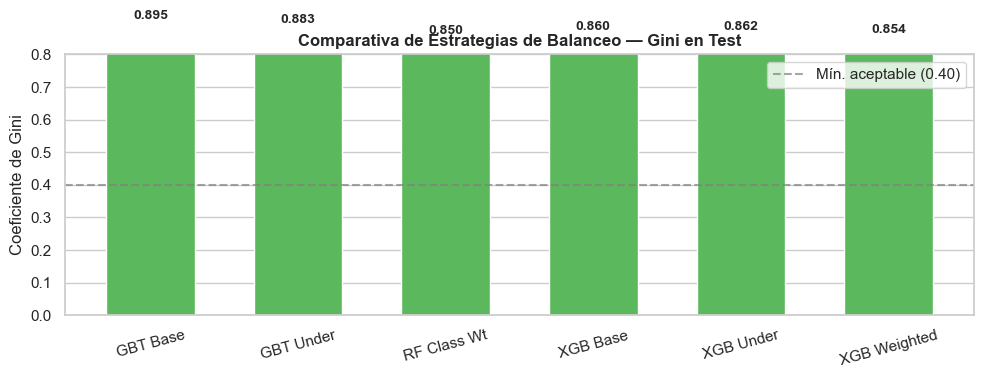


✅ Mejor modelo XGBoost seleccionado para módulos posteriores: XGB Under


In [55]:
# ── Comparativa visual de los 6 modelos ──────────────────────────────────────
modelos_m1 = [
    ('GBT Base',       model_base),
    ('GBT Under',      model_under),
    ('RF Class Wt',    model_weighted),
    ('XGB Base',       xgb_base),
    ('XGB Under',      xgb_under),
    ('XGB Weighted',   xgb_weighted),
]
ginis_m1 = [(name, calcular_gini(m, X_test, y_test)) for name, m in modelos_m1]

nombres, valores = zip(*ginis_m1)
colores = ['#d9534f' if v < 0.25 else '#f0ad4e' if v < 0.40 else '#5cb85c' for v in valores]

plt.figure(figsize=(10, 4))
bars = plt.bar(nombres, valores, color=colores, edgecolor='white', width=0.6)
plt.axhline(0.40, linestyle='--', color='gray', alpha=0.7, label='Mín. aceptable (0.40)')
for bar, val in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Comparativa de Estrategias de Balanceo — Gini en Test', fontweight='bold')
plt.ylabel('Coeficiente de Gini')
plt.ylim(0, 0.8)
plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Seleccionamos el mejor modelo XGBoost para los módulos posteriores
mejor_xgb_nombre = max(ginis_m1[3:], key=lambda x: x[1])[0]
mejor_xgb_modelo = dict(modelos_m1)[mejor_xgb_nombre]
print(f'\n✅ Mejor modelo XGBoost seleccionado para módulos posteriores: {mejor_xgb_nombre}')

---
## Módulo 2 — Validación: Gini, KS y Curva ROC
El **Coeficiente de Gini** y el **Estadístico KS** son fundamentales. 
* El Gini mide la capacidad de separación de las curvas.
* El KS mide la máxima distancia entre la distribución acumulada de buenos y malos pagadores.
Evaluamos el mejor modelo XGBoost con las métricas estándar de la industria bancaria.

| Métrica | Fórmula | Umbral Aceptable |
|---|---|---|
| **Gini** | 2 × AUC − 1 | > 0.40 |
| **KS** | max(TPR − FPR) | > 0.30 |
| **AUC** | Área bajo ROC | > 0.70 |

AUC  = 0.9311
Gini = 0.8623  → ✅ Aceptable
KS   = 0.7537   → ✅ Bueno


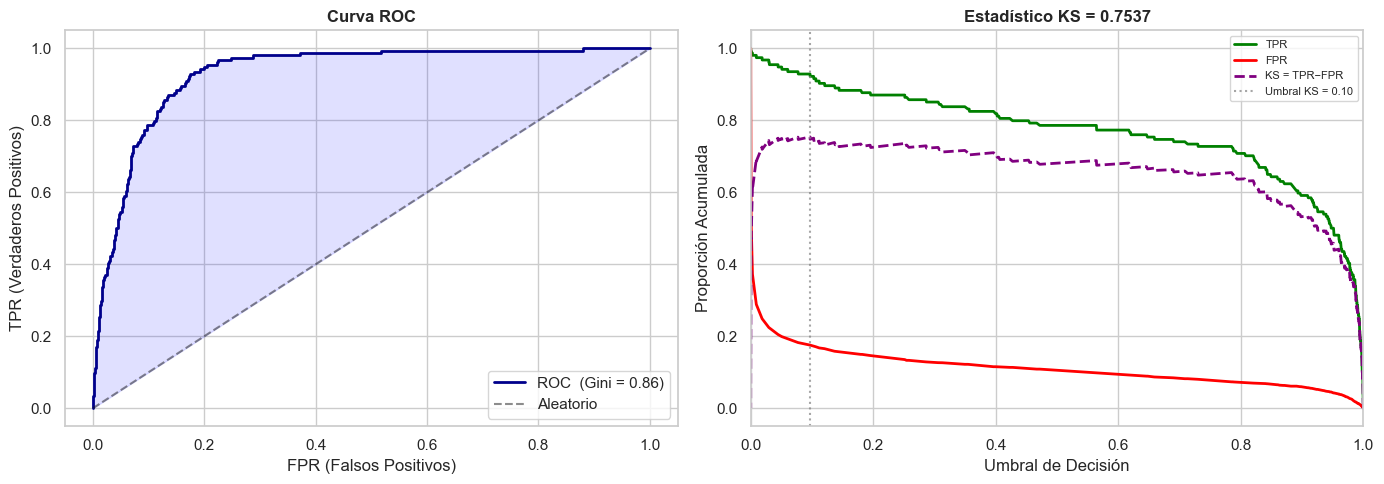

In [56]:
# ── Métricas del mejor modelo XGBoost ────────────────────────────────────────
#
# ⓘ probs y gini_val se definen aquí y son referenciados por Módulos 3 y 5.
#    Siempre apuntan al mejor_xgb_modelo para mantener consistencia.

probs    = mejor_xgb_modelo.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)

auc_val  = roc_auc_score(y_test, probs)
gini_val = 2 * auc_val - 1
ks_val   = float(max(tpr - fpr))

print(f'AUC  = {auc_val:.4f}')
print(f'Gini = {gini_val:.4f}  → {"✅ Aceptable" if gini_val >= 0.40 else "⚠️  Revisar"}')
print(f'KS   = {ks_val:.4f}   → {"✅ Bueno"     if ks_val   >= 0.30 else "⚠️  Revisar"}')

# ── Gráficas ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Curva ROC
axes[0].plot(fpr, tpr, color='darkblue', lw=2,
             label=f'ROC  (Gini = {gini_val:.2f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
axes[0].fill_between(fpr, tpr, fpr, alpha=0.12, color='blue')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].set_xlabel('FPR (Falsos Positivos)')
axes[0].set_ylabel('TPR (Verdaderos Positivos)')
axes[0].legend()

# Panel 2: Estadístico KS
ks_idx = int(np.argmax(tpr - fpr))
axes[1].plot(thresholds, tpr, color='green', lw=2, label='TPR')
axes[1].plot(thresholds, fpr, color='red',   lw=2, label='FPR')
axes[1].plot(thresholds, tpr - fpr, color='purple', lw=2, linestyle='--', label='KS = TPR−FPR')
axes[1].axvline(x=thresholds[ks_idx], color='gray', linestyle=':', alpha=0.7,
                label=f'Umbral KS = {thresholds[ks_idx]:.2f}')
axes[1].set_title(f'Estadístico KS = {ks_val:.4f}', fontweight='bold')
axes[1].set_xlabel('Umbral de Decisión')
axes[1].set_ylabel('Proporción Acumulada')
axes[1].set_xlim([0, 1])
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Módulo 3 — Impacto en el Negocio: Pérdida Esperada

$$\boxed{EL = PD \times LGD \times EAD}$$

| Componente | Descripción | Fuente |
|---|---|---|
| **PD** | Probabilidad de Incumplimiento | Salida del modelo XGBoost |
| **LGD** | Loss Given Default | Parámetro fijo: 45% |
| **EAD** | Exposure at Default | `monto_credito` |

       RESUMEN DE CARTERA EVALUADA
Exposición Total       : $    284,468,547
Reservas a Constituir  : $     16,559,539
Ratio EL / Cartera     : 5.82%

               Clientes  PD_promedio     EL_total  EL_promedio
Rating                                                        
Bajo (<5%)         3487         0.00    339344.98        97.32
Medio (5-20%)       252         0.11    754351.72      2993.46
Alto (>20%)         761         0.74  15465842.11     20323.05


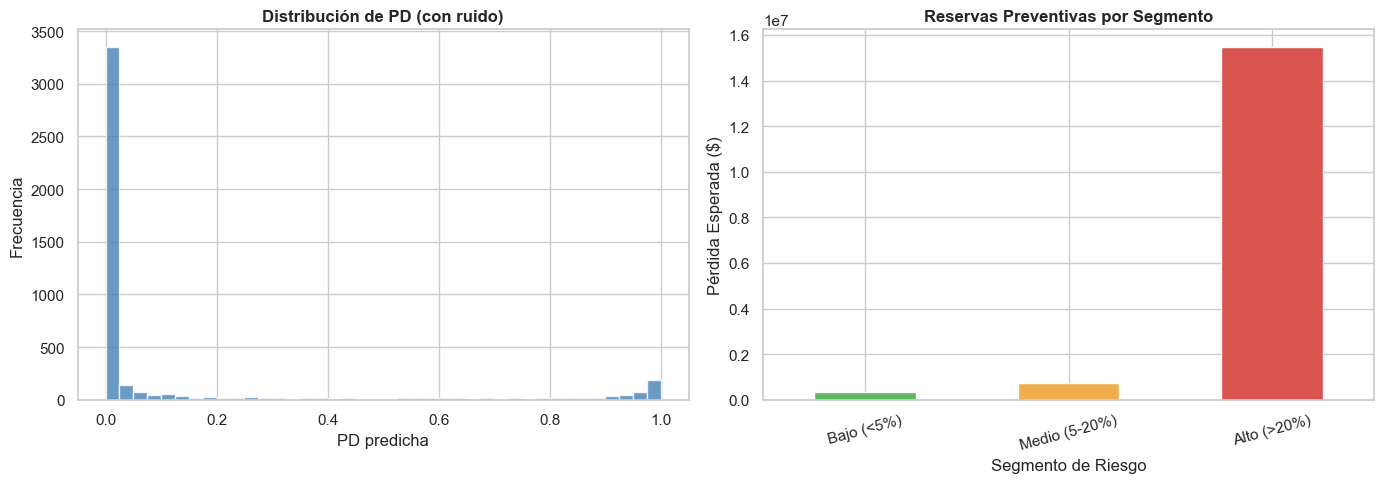

In [57]:
# ── Cálculo de Pérdida Esperada ───────────────────────────────────────────────
LGD = 0.45

df_portfolio = X_test.copy()
df_portfolio['PD']           = probs   # ← PD del mejor modelo XGBoost (Módulo 2)
df_portfolio['EL']           = df_portfolio['PD'] * LGD * df_portfolio['monto_credito']
df_portfolio['default_real'] = y_test.values
df_portfolio['Rating']       = pd.cut(
    df_portfolio['PD'],
    bins=[0, 0.05, 0.20, 1.0],
    labels=['Bajo (<5%)', 'Medio (5-20%)', 'Alto (>20%)']
)

print('=' * 55)
print('       RESUMEN DE CARTERA EVALUADA')
print('=' * 55)
print(f'Exposición Total       : ${df_portfolio["monto_credito"].sum():>15,.0f}')
print(f'Reservas a Constituir  : ${df_portfolio["EL"].sum():>15,.0f}')
print(f'Ratio EL / Cartera     : {df_portfolio["EL"].sum() / df_portfolio["monto_credito"].sum() * 100:.2f}%')
print()

summary = df_portfolio.groupby('Rating', observed=True).agg(
    Clientes    =('PD', 'count'),
    PD_promedio =('PD', 'mean'),
    EL_total    =('EL', 'sum'),
    EL_promedio =('EL', 'mean')
).round(2)
print(summary.to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_portfolio['PD'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de PD (con ruido)', fontweight='bold')
axes[0].set_xlabel('PD predicha')
axes[0].set_ylabel('Frecuencia')

el_by_rating = df_portfolio.groupby('Rating', observed=True)['EL'].sum()
el_by_rating.plot(kind='bar', ax=axes[1],
                  color=['#5cb85c', '#f0ad4e', '#d9534f'], edgecolor='white')
axes[1].set_title('Reservas Preventivas por Segmento', fontweight='bold')
axes[1].set_xlabel('Segmento de Riesgo')
axes[1].set_ylabel('Pérdida Esperada ($)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

---
## Módulo 4 — SQL para Inteligencia de Datos de Riesgo
En esta sección simularemos un entorno de base de datos bancaria para practicar:
1. **Análisis de Cohortes (Vintage Analysis):** Para ver cómo madura la mora según el mes de colocación.
2. **Window Functions:** Para calcular promedios móviles y comportamiento histórico por cliente.
3. **Optimización:** Uso de CTEs (Common Table Expressions) y filtrado eficiente.

In [58]:
# ── Setup: SQLite en memoria ──────────────────────────────────────────────────
conn = sqlite3.connect(':memory:')

conn.execute('''
CREATE TABLE creditos (
    id_credito     INTEGER PRIMARY KEY,
    fecha_apertura DATE,
    cliente_id     INTEGER,
    monto_otorgado REAL
)''')

conn.execute('''
CREATE TABLE pagos (
    id_pago     INTEGER PRIMARY KEY,
    id_credito  INTEGER,
    fecha_pago  DATE,
    monto_pagado REAL,
    dias_atraso  INTEGER
)''')

conn.executemany('INSERT INTO creditos VALUES (?,?,?,?)', [
    (1, '2025-01-15', 101, 50_000),
    (2, '2025-01-20', 102, 30_000),
    (3, '2025-02-10', 103, 45_000),
    (4, '2025-02-25', 104, 60_000)
])

# ⓘ id_pago únicos — bug corregido respecto a la versión original del notebook
conn.executemany('INSERT INTO pagos VALUES (?,?,?,?,?)', [
    (1, 1, '2025-02-15', 2_000,  0),
    (2, 1, '2025-03-15', 2_000,  5),
    (3, 1, '2025-04-15', 2_000, 32),
    (4, 2, '2025-02-20', 1_500,  0),
    (5, 2, '2025-03-20', 1_500,  0),
    (6, 2, '2025-04-20', 1_500,  0),
    (7, 3, '2025-03-10', 1_800,  0),
    (8, 3, '2025-04-10', 1_800, 15)
])
print('✅ Entorno SQL configurado')

✅ Entorno SQL configurado


## 4.1. Análisis de Cohortes (Vintage Analysis)
El análisis de "cosechas" es vital. Queremos saber: "De los créditos otorgados en Enero, ¿qué porcentaje está en mora de más de 30 días a los 3 meses de vida?".

In [59]:
# ── 4.1 Vintage Analysis ──────────────────────────────────────────────────────
query_cohortes = '''
WITH Cosechas AS (
    SELECT strftime('%Y-%m', fecha_apertura) AS mes_cosecha,
           id_credito
    FROM creditos
),
Mora AS (
    SELECT p.id_credito, p.dias_atraso,
           (strftime('%Y', p.fecha_pago) - strftime('%Y', c.fecha_apertura)) * 12
           + (strftime('%m', p.fecha_pago) - strftime('%m', c.fecha_apertura)) AS meses_de_vida
    FROM pagos p
    JOIN creditos c ON p.id_credito = c.id_credito
)
SELECT
    c.mes_cosecha,
    m.meses_de_vida,
    COUNT(DISTINCT c.id_credito)                                                   AS num_creditos,
    SUM(CASE WHEN m.dias_atraso > 30 THEN 1 ELSE 0 END)                           AS en_mora_30,
    ROUND(CAST(SUM(CASE WHEN m.dias_atraso > 30 THEN 1 ELSE 0 END) AS REAL)
          / COUNT(DISTINCT c.id_credito) * 100, 2)                                AS tasa_mora_pct
FROM Cosechas c
LEFT JOIN Mora m ON c.id_credito = m.id_credito
GROUP BY 1, 2
ORDER BY 1, 2;
'''
print('--- Vintage Analysis ---')
pd.read_sql_query(query_cohortes, conn)

--- Vintage Analysis ---


,mes_cosecha,meses_de_vida,num_creditos,en_mora_30,tasa_mora_pct
0,2025-01,1.0,2,0,0.0
1,2025-01,2.0,2,0,0.0
2,2025-01,3.0,2,1,50.0
3,2025-02,NaN,1,0,0.0
4,2025-02,1.0,1,0,0.0
5,2025-02,2.0,1,0,0.0


## 4.2 Ventanas de Tiempo (Window Functions)
Las funciones de ventana nos permiten mirar hacia atrás en el historial de un cliente sin colapsar las filas. 
**Escenario:** Necesitamos calcular el "Atraso Máximo" que ha tenido un cliente en los últimos 3 pagos para usarlo como variable en el modelo de comportamiento.

In [60]:
# ── 4.2 Window Functions ──────────────────────────────────────────────────────
query_ventanas = '''
SELECT
    id_credito, fecha_pago, dias_atraso,
    MAX(dias_atraso) OVER (
        PARTITION BY id_credito ORDER BY fecha_pago
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS max_atraso_historico,
    ROUND(AVG(CAST(dias_atraso AS REAL)) OVER (
        PARTITION BY id_credito ORDER BY fecha_pago
        ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
    ), 1) AS avg_atraso_ventana_2,
    ROW_NUMBER() OVER (PARTITION BY id_credito ORDER BY fecha_pago) AS num_pago
FROM pagos
ORDER BY id_credito, fecha_pago;
'''
print('--- Window Functions ---')
pd.read_sql_query(query_ventanas, conn)

--- Window Functions ---


,id_credito,fecha_pago,dias_atraso,max_atraso_historico,avg_atraso_ventana_2,num_pago
0,1,2025-02-15,0,0,0.0,1
1,1,2025-03-15,5,5,2.5,2
2,1,2025-04-15,32,32,18.5,3
3,2,2025-02-20,0,0,0.0,1
4,2,2025-03-20,0,0,0.0,2
5,2,2025-04-20,0,0,0.0,3
6,3,2025-03-10,0,0,0.0,1
7,3,2025-04-10,15,15,7.5,2


## 4.3 Optimización en Ambientes de Producción
En un banco con millones de filas, una mala consulta puede tirar el servidor.

### Reglas de Oro:
1. **Filtrado Temprano (SARGability):** Usa `WHERE` antes de los `JOINs` siempre que sea posible. Evita funciones en las columnas del `WHERE` (ej. usar `fecha >= '2025-01-01'` en lugar de `YEAR(fecha) = 2025`).
2. **Uso de CTEs vs Subconsultas:** Las CTEs (`WITH...`) hacen el código más legible y permiten al optimizador de consultas estructurar mejor el plan de ejecución.
3. **Índices:** Asegúrate de que las columnas usadas en los `JOIN` (`id_credito`, `cliente_id`) y filtros frecuentes (`fecha_apertura`) tengan índices.

**Ejemplo de optimización:**
En lugar de traer todos los pagos y luego filtrar, filtramos la tabla de pagos antes del JOIN para reducir el volumen de datos en memoria.

In [61]:
# ── 4.3 CTE Optimizada: Filtrado Temprano ────────────────────────────────────
#
# ⓘ Anti-patrón: WHERE YEAR(fecha_pago) = 2025  ← no usa índices (no SARGable)
#    Patrón correcto: WHERE fecha_pago >= '2025-01-01'  ← usa índices (SARGable)

query_optimizado = '''
WITH pagos_recientes AS (
    SELECT id_credito, fecha_pago, dias_atraso
    FROM pagos
    WHERE fecha_pago >= '2025-03-01'  -- Filtro temprano antes del JOIN
)
SELECT
    c.id_credito, c.monto_otorgado,
    pr.fecha_pago, pr.dias_atraso,
    CASE
        WHEN pr.dias_atraso = 0             THEN 'Al corriente'
        WHEN pr.dias_atraso BETWEEN 1 AND 30 THEN 'Mora temprana'
        ELSE                                     'Mora crítica'
    END AS estatus_pago
FROM creditos c
INNER JOIN pagos_recientes pr ON c.id_credito = pr.id_credito
WHERE c.monto_otorgado > 10_000
ORDER BY c.id_credito, pr.fecha_pago;
'''
print('--- CTE Optimizada ---')
pd.read_sql_query(query_optimizado, conn)

--- CTE Optimizada ---


,id_credito,monto_otorgado,fecha_pago,dias_atraso,estatus_pago
0,1,50000.0,2025-03-15,5,Mora temprana
1,1,50000.0,2025-04-15,32,Mora crítica
2,2,30000.0,2025-03-20,0,Al corriente
3,2,30000.0,2025-04-20,0,Al corriente
4,3,45000.0,2025-03-10,0,Al corriente
5,3,45000.0,2025-04-10,15,Mora temprana


---
## Módulo 5 — Backtesting (OOT) y PSI
Un modelo en producción es un organismo vivo. La responsabilidad de un Coordinador es asegurar que el modelo siga siendo válido meses después de su implementación.

Backtesting: ¿Qué tan bien predijo el modelo en datos que no vio durante el entrenamiento (Out-of-Time)?
PSI (Population Stability Index): ¿Ha cambiado la población que solicita crédito hoy respecto a la que usamos para entrenar?
### ¿Por qué el ruido importa aquí?
El dataset OOT también incluye ruido, consistente con el de entrenamiento. Si el OOT **no** tuviera ruido, el Gini OOT sería artificialmente más alto que el real, dando una falsa sensación de estabilidad.

## 5.1 Backtesting (Out-of-Time - OOT)
En riesgos, no basta con `train_test_split` aleatorio. Debemos probar el modelo con un mes completo que sea posterior al entrenamiento. Esto simula la vida real.

**Métrica clave:** Degradación del Gini. Si el Gini en entrenamiento es 0.70 y en el OOT es 0.40, el modelo no es robusto.

In [62]:
# ── 5.1 Backtesting Out-of-Time ───────────────────────────────────────────────
np.random.seed(99)
N_OOT = 2_000

data_oot = {
    'ingreso_mensual':    np.random.normal(24_000, 8_500, N_OOT),
    'dti':                np.random.uniform(0.15, 0.75, N_OOT),
    'score_buro':         np.random.normal(630, 70, N_OOT),
    'antiguedad_laboral': np.random.uniform(0, 15, N_OOT),
    'monto_credito':      np.random.uniform(5_000, 120_000, N_OOT)
}
df_oot = pd.DataFrame(data_oot)

# Mismo logit + ruido consistente con el entrenamiento
logit_oot = (0.007 * (680 - df_oot['score_buro'])
             + 3.5  * df_oot['dti']
             - 0.0001 * df_oot['ingreso_mensual'])
ruido_oot           = np.random.normal(0, 0.15, N_OOT)
prob_oot_real       = np.clip(1 / (1 + np.exp(-logit_oot)) + ruido_oot, 0, 1)
df_oot['target']    = (prob_oot_real > 0.80).astype(int)

# Evaluación del modelo
probs_oot = mejor_xgb_modelo.predict_proba(df_oot.drop('target', axis=1))[:, 1]
gini_oot  = 2 * roc_auc_score(df_oot['target'], probs_oot) - 1
degradacion = (gini_val - gini_oot) / gini_val * 100

print('=' * 48)
print('       RESULTADO DE BACKTESTING OOT')
print('=' * 48)
print(f'Gini en TEST (In-Time)  : {gini_val:.4f}')
print(f'Gini en OOT             : {gini_oot:.4f}')
print(f'Degradación             : {degradacion:.2f}%')
print()
if degradacion < 10:
    print('✅ Modelo robusto: degradación < 10%')
elif degradacion < 20:
    print('⚠️  Aceptable: monitorear de cerca')
else:
    print('🛑 Inestable: considerar reentrenamiento')

       RESULTADO DE BACKTESTING OOT
Gini en TEST (In-Time)  : 0.8623
Gini en OOT             : 0.8340
Degradación             : 3.28%

✅ Modelo robusto: degradación < 10%


## 2. Population Stability Index (PSI)
El PSI mide cuánto ha cambiado la distribución de una variable o del Score final.

**Fórmula:** $PSI = \sum (Actual\% - Expected\%) \times \ln(Actual\% / Expected\%)$

**Interpretación:**
* **PSI < 0.10:** Sin cambios significativos (Estable).
* **0.10 < PSI < 0.25:** Cambio moderado (Requiere revisión).
* **PSI > 0.25:** Cambio significativo (El modelo debe recalibrarse o detenerse).

### Implementación del PSI (Population Stability Index)
---
Esta es la implementación de la fórmula estándar de la industria bancaria para medir el **Model Drift**:

$$PSI = \sum_{i=1}^{n} \left( Actual\_i - Expected\_i \right) \times \ln \left( \frac{Actual\_i}{Expected\_i} \right)$$

**¿Cómo funciona la penalización?**
* **Sensibilidad:** La ecuación penaliza fuertemente a los grupos donde la proporción de clientes cambió drásticamente entre el entrenamiento (*Expected*) y la producción (*Actual*).
* **Cero Desviación:** Si un segmento antes concentraba al **10%** de los clientes y actualmente mantiene ese **10%**, esa parte de la suma es $0 \times \ln(1) = 0$. 
* **Resultado:** Si todos los grupos se mantienen idénticos, tu **PSI es 0**. A mayor cambio en la distribución, mayor será el valor del índice.

PSI del Score Final : 0.0963
✅ ESTABLE


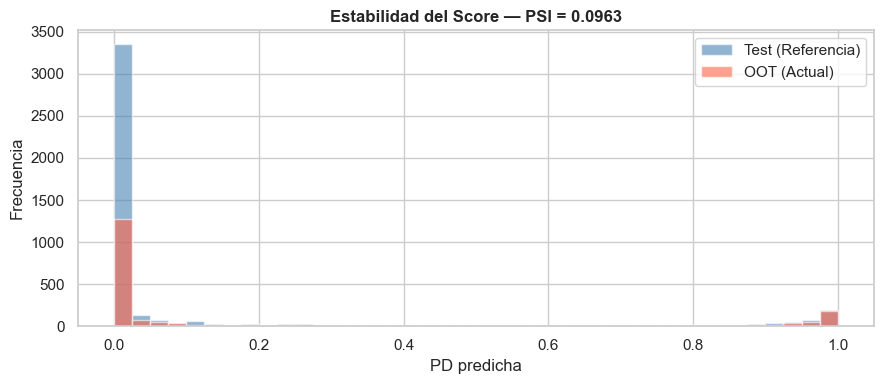

In [63]:
# ── 5.2 Population Stability Index (PSI) ─────────────────────────────────────
#
# Fórmula: PSI = Σ (Actual% − Expected%) × ln(Actual% / Expected%)

def calculate_psi(expected: np.ndarray, actual: np.ndarray, buckets: int = 10) -> float:
    """Calcula el PSI entre dos distribuciones.
    expected : distribución de referencia (scores en entrenamiento/test)
    actual   : distribución actual (scores en OOT o producción)
    """
    breakpoints    = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    exp_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    act_pct = np.histogram(actual,   bins=breakpoints)[0] / len(actual)

    exp_pct = np.where(exp_pct == 0, 1e-4, exp_pct)
    act_pct = np.where(act_pct == 0, 1e-4, act_pct)

    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))


psi_score = calculate_psi(probs, probs_oot)

print(f'PSI del Score Final : {psi_score:.4f}')
if psi_score < 0.10:
    print('✅ ESTABLE')
elif psi_score < 0.25:
    print('⚠️  ADVERTENCIA — Cambio moderado')
else:
    print('🛑 ACCIÓN REQUERIDA — Recalibrar modelo')

plt.figure(figsize=(9, 4))
plt.hist(probs,     bins=40, alpha=0.6, color='steelblue', label='Test (Referencia)')
plt.hist(probs_oot, bins=40, alpha=0.6, color='tomato',    label='OOT (Actual)')
plt.title(f'Estabilidad del Score — PSI = {psi_score:.4f}', fontweight='bold')
plt.xlabel('PD predicha')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

---
## Módulo 6 — Scorecards y Calificación Paramétrica

Transformamos la PD (0–1) en un **Score de puntos** (0–1000).

**PDO (Points to Double Odds):** cada `pdo` puntos, la confianza de que el cliente pague se duplica.

In [64]:
# ── Función de Escalamiento PD → Score ───────────────────────────────────────
#
# 🐛 CORRECCIÓN: parámetro renombrado de `pd` a `pd_value`.
#    El nombre `pd` en el scope local sobreescribía el alias global de pandas,
#    causando errores silenciosos en cualquier celda que usara `pd.` después.

def pd_to_score(pd_value: float,
                target_score: int   = 600,
                target_odds:  float = 50.0,
                pdo:          int   = 20) -> float:
    """
    Convierte una Probabilidad de Incumplimiento (PD) a Score de puntos.

    Parameters
    ----------
    pd_value     : PD del modelo (entre 0 y 1)
    target_score : score de calibración (default 600)
    target_odds  : odds en el target_score = P(pago) / P(default)
    pdo          : Points to Double the Odds

    Returns
    -------
    float : score (mayor = cliente más seguro)
    """
    factor    = pdo / np.log(2)
    offset    = target_score - factor * np.log(target_odds)
    pd_value  = np.clip(pd_value, 1e-4, 1 - 1e-4)
    odds      = (1 - pd_value) / pd_value
    return offset + factor * np.log(odds)


def asignar_rating(score: float) -> str:
    if   score >= 800: return 'A1 — Excelente'
    elif score >= 700: return 'A2 — Muy Bueno'
    elif score >= 600: return 'B1 — Bueno'
    elif score >= 500: return 'B2 — Aceptable'
    elif score >= 400: return 'C1 — Riesgo Moderado'
    else:              return 'D/E — Riesgo Crítico'


df_portfolio['Score']        = df_portfolio['PD'].apply(pd_to_score)
df_portfolio['Calificacion'] = df_portfolio['Score'].apply(asignar_rating)

print('--- Muestra: PD → Score → Calificación ---')
print(df_portfolio[['PD', 'Score', 'Calificacion']].head(8).to_string(index=False))
print()
print('--- Distribución de Cartera por Calificación (%) ---')
dist = (df_portfolio['Calificacion']
        .value_counts(normalize=True)
        .mul(100).round(2)
        .rename('Porcentaje (%)')
        .sort_index())
print(dist.to_string())

--- Muestra: PD → Score → Calificación ---
      PD      Score         Calificacion
0.906054 421.728961 C1 — Riesgo Moderado
0.003554 649.749491           B1 — Bueno
0.001533 674.070729           B1 — Bueno
0.009593 620.919325           B1 — Bueno
0.000343 717.303603       A2 — Muy Bueno
0.000725 695.684282           B1 — Bueno
0.000201 732.769660       A2 — Muy Bueno
0.010467 618.380119           B1 — Bueno

--- Distribución de Cartera por Calificación (%) ---
Calificacion
A2 — Muy Bueno          45.96
B1 — Bueno              27.11
B2 — Aceptable          12.96
C1 — Riesgo Moderado     8.36
D/E — Riesgo Crítico     5.62


---
## Módulo 7 — XGBoost con Restricciones de Monotonicidad

El **ruido en los datos hace que las restricciones de monotonicidad sean aún más importantes**. Sin ellas, el modelo podría aprender relaciones espurias del ruido (ej: a mayor ingreso → más default). La monotonicidad garantiza que la lógica económica prevalezca sobre el ruido.

| Restricción | Significado | Variable |
|---|---|---|
| `+1` | A mayor X → mayor riesgo | DTI |
| `-1` | A mayor X → menor riesgo | Ingreso, Score Buró |
| `0` | Sin restricción | Monto crédito |

In [65]:
# ── XGBoost con Monotonicity Constraints ──────────────────────────────────────
# Definimos las restricciones para nuestras variables
# +1: Incremental, -1: Decremental, 0: Sin restricción
monotone_constraints = {
    'ingreso_mensual':    -1, # A más ingreso, menos default
    'dti':                +1, # A más deuda, más default
    'score_buro':         -1, # A más score, menos default
    'antiguedad_laboral': -1, # A más antigüedad, menos default
    'monto_credito':       0
}
constraints_tuple = tuple(monotone_constraints[col] for col in X_train.columns)
print(f'Restricciones : {dict(zip(X_train.columns, constraints_tuple))}')

model_monotone = xgb.XGBClassifier(
    n_estimators         = 150,
    learning_rate        = 0.05,
    max_depth            = 5,
    monotone_constraints = constraints_tuple,
    eval_metric          = 'auc',
    random_state         = 42
)
model_monotone.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = False
)

gini_monotone = calcular_gini(model_monotone, X_test, y_test)
print(f'\nGini XGBoost Monotone : {gini_monotone:.4f}')
print(f'Gini XGBoost Weighted : {calcular_gini(xgb_weighted, X_test, y_test):.4f}')
print(f'\n→ Costo de la monotonicidad: ~{calcular_gini(xgb_weighted, X_test, y_test) - gini_monotone:.4f} Gini')
print('  Ese costo es el precio de la interpretabilidad y la defensa ante el comité.')

# Feature Importance para documentación
fi = pd.DataFrame({
    'Variable':    X_train.columns,
    'Importancia': model_monotone.feature_importances_
}).sort_values('Importancia', ascending=False)
print('\n--- Feature Importance (Anexo Técnico) ---')
print(fi.to_string(index=False))

Restricciones : {'ingreso_mensual': -1, 'dti': 1, 'score_buro': -1, 'antiguedad_laboral': -1, 'monto_credito': 0}

Gini XGBoost Monotone : 0.8856
Gini XGBoost Weighted : 0.8535

→ Costo de la monotonicidad: ~-0.0321 Gini
  Ese costo es el precio de la interpretabilidad y la defensa ante el comité.

--- Feature Importance (Anexo Técnico) ---
          Variable  Importancia
   ingreso_mensual     0.420880
               dti     0.339551
        score_buro     0.158355
antiguedad_laboral     0.040769
     monto_credito     0.040445


---
## Módulo 8 — Interpretabilidad con SHAP

SHAP responde: *¿Cuánto aportó cada variable a la predicción de **este** cliente específico?*

### ⚠️ Diferencia crítica: XGBoost vs RandomForest

| Modelo | `shap_values` retorna | Para clase positiva |
|---|---|---|
| **XGBoost** (binario) | array 2D `[n, features]` | Usar directamente |
| **RandomForest** (binario) | lista de 2 arrays `[clase0, clase1]` | Usar `[1]` |

Shape de shap_values (XGBoost): (4500, 5)  ← array 2D directo


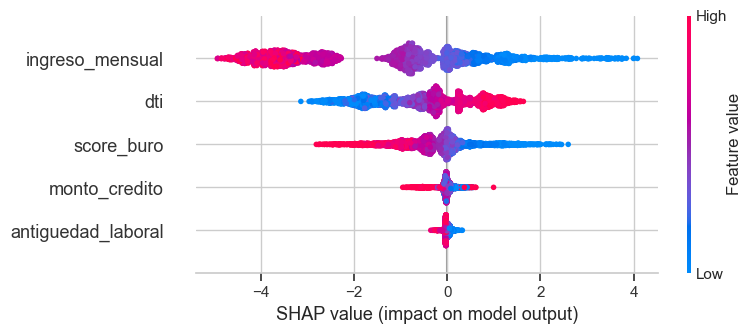

In [66]:
# ── 8.1 SHAP Global — XGBoost Monotone ───────────────────────────────────────
explainer_xgb  = shap.TreeExplainer(model_monotone)
shap_values_xgb = explainer_xgb.shap_values(X_test)

print(f'Shape de shap_values (XGBoost): {shap_values_xgb.shape}  ← array 2D directo')
shap.summary_plot(shap_values_xgb, X_test, plot_type='dot', show=True)

Cliente #0:
ingreso_mensual        14245.231961
dti                        0.492527
score_buro               651.770016
antiguedad_laboral         7.933966
monto_credito         116432.250871

PD predicha  : 0.1003
Default real : 0


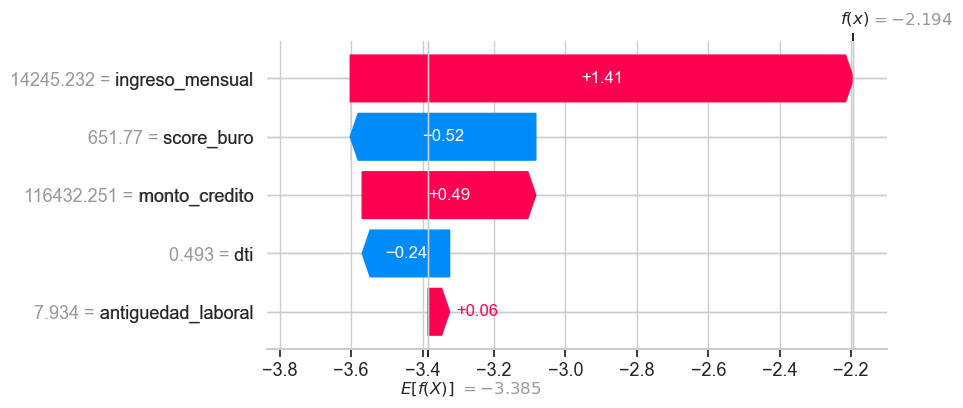

In [67]:
# ── 8.2 SHAP Local — Explicar un cliente individual ───────────────────────────
cliente_idx = 0   # Cambia este índice para explorar otros clientes

print(f'Cliente #{cliente_idx}:')
print(X_test.iloc[cliente_idx].to_string())
print(f'\nPD predicha  : {model_monotone.predict_proba(X_test)[cliente_idx, 1]:.4f}')
print(f'Default real : {y_test.iloc[cliente_idx]}')

shap_exp = shap.Explanation(
    values        = shap_values_xgb[cliente_idx],
    base_values   = explainer_xgb.expected_value,
    data          = X_test.iloc[cliente_idx].values,
    feature_names = X_test.columns.tolist()
)
shap.waterfall_plot(shap_exp)

Summary Plot (Beeswarm) - Clase Positiva (Default):


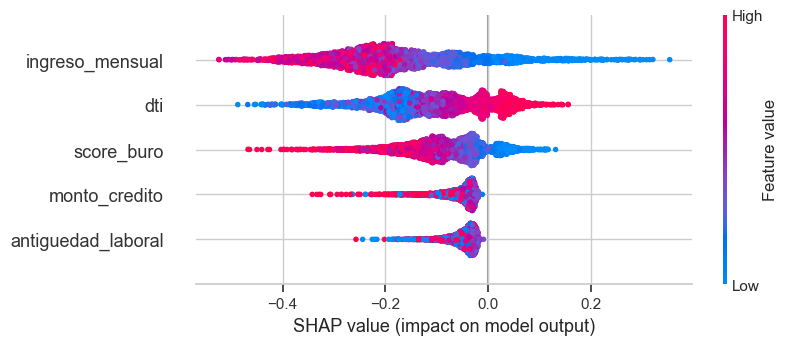


Waterfall SHAP — RandomForest — Cliente #0:


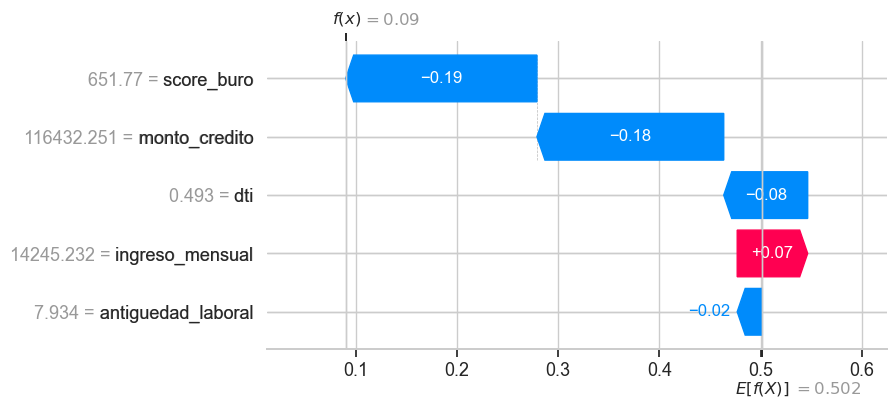

In [69]:
# ── 8.3 SHAP con RandomForest — Versión Moderna ─────────────────────────────

# 1. Aseguramos que los datos tengan SOLO las columnas de entrenamiento
cols_entrenamiento = ['ingreso_mensual', 'dti', 'score_buro', 'antiguedad_laboral', 'monto_credito']
X_test_clean = X_test[cols_entrenamiento]

# 2. Crear el explainer (TreeExplainer es ideal para Random Forest)
explainer_rf = shap.TreeExplainer(model_weighted)

# 3. Generar el objeto Explanation (API MODERNA)
# Pasamos X_test_clean para asegurar que las dimensiones coincidan desde el inicio
shap_values_obj = explainer_rf(X_test_clean)

# 4. Seleccionar la clase positiva (Clase 1 = Default)
# En Random Forest, el objeto resultante es (filas, variables, clases).
# Seleccionamos [todas las filas, todas las variables, clase 1]
shap_pos_class = shap_values_obj[:, :, 1]

# 5. Graficar Summary Plot (Beeswarm o Bar)
print("Summary Plot (Beeswarm) - Clase Positiva (Default):")
# La nueva API detecta automáticamente si pasas el objeto de la clase 1
shap.plots.beeswarm(shap_pos_class)

# O si prefieres el de barras:
# shap.plots.bar(shap_pos_class)

# 6. Waterfall Plot para un cliente específico
# El objeto shap_pos_class ya contiene los nombres de las columnas y el valor base
print(f"\nWaterfall SHAP — RandomForest — Cliente #{cliente_idx}:")
shap.plots.waterfall(shap_pos_class[cliente_idx])

---
## 📋 Cheat Sheet

| Pregunta probable | Respuesta clave |
|---|---|
| *¿Por qué añadir ruido al target?* | Porque el default real tiene una componente irreducible. Modelos entrenados sin ruido sobreestiman el Gini real en producción |
| *¿Qué es `scale_pos_weight`?* | El equivalente XGBoost de `class_weight='balanced'`. Se calcula como `n_negativos / n_positivos` y penaliza matemáticamente los errores en la clase minoritaria |
| *¿Por qué XGBoost sobre RF?* | Nativo de restricciones de monotonicidad, `scale_pos_weight`, compatible con SHAP, mejor control de overfitting con `learning_rate` y `max_depth` |
| *¿Qué es el PSI?* | Mide si la población cambió desde que entrenamos. PSI > 0.25 → recalibrar |
| *¿Qué es el Gini?* | `2 × AUC − 1`. Mide discriminación. En consumo, aceptamos ≥ 0.40 |
| *¿Por qué SHAP sobre Feature Importance?* | SHAP da magnitud **y** dirección por cliente individual, no solo ranking global |
| *¿Qué es EL = PD × LGD × EAD?* | La Pérdida Esperada de Basilea III. Determina las reservas preventivas |